# 01 - Veri Analizi
Normal vs anormal ses karşılaştırması.

In [1]:
import os, glob
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


In [2]:
# ── AYARLAR ──────────────────────────────────────────
BASE_DIR     = r'd:/AcoustiGuard/AcoustiGuard'
MACHINE_TYPE = 'fan'
MODEL_ID     = 'id_00'   # id_00 / id_02 / id_04 / id_06
SAMPLE_RATE  = 16000
CHANNEL      = 0
# ─────────────────────────────────────────────────────

machine_dir = os.path.join(BASE_DIR, 'data', 'raw', 'mimii', MACHINE_TYPE, MODEL_ID)
os.makedirs(os.path.join(BASE_DIR, 'outputs'), exist_ok=True)
print(f'Veri dizini: {machine_dir}')

Veri dizini: d:/AcoustiGuard/AcoustiGuard\data\raw\mimii\fan\id_00


## 1. Dosya Sayıları

In [3]:
rows = []
for lbl in ['normal', 'abnormal']:
    folder = os.path.join(machine_dir, lbl)
    files  = glob.glob(os.path.join(folder, '*.wav'))
    rows.append({'Label': lbl, 'Dosya Sayısı': len(files)})
df = pd.DataFrame(rows)
display(df)
n_normal   = rows[0]['Dosya Sayısı']
n_abnormal = rows[1]['Dosya Sayısı']
print(f'\nDengesizlik: {n_normal/max(n_abnormal,1):.1f}x daha fazla normal')
print(f'Train (normal %80): {int(n_normal*0.8)}')
print(f'Test  (normal %20 + abnormal): {int(n_normal*0.2) + n_abnormal}')

,Label,Dosya Sayısı
0,normal,1011
1,abnormal,407



Dengesizlik: 2.5x daha fazla normal
Train (normal %80): 808
Test  (normal %20 + abnormal): 609


## 2. Ses Yükle ve Dinle

In [4]:
def load_wav(path, sr=SAMPLE_RATE, ch=CHANNEL):
    y, _ = librosa.load(path, sr=sr, mono=False)
    return y[ch] if y.ndim > 1 else y

normal_files   = sorted(glob.glob(os.path.join(machine_dir, 'normal',   '*.wav')))
abnormal_files = sorted(glob.glob(os.path.join(machine_dir, 'abnormal', '*.wav')))

y_normal   = load_wav(normal_files[0])
y_abnormal = load_wav(abnormal_files[0])

print(f'Normal  : {len(y_normal)/SAMPLE_RATE:.1f} sn')
print(f'Anormal : {len(y_abnormal)/SAMPLE_RATE:.1f} sn')
print('\nNormal ses:')
display(Audio(y_normal, rate=SAMPLE_RATE))
print('Anormal ses:')
display(Audio(y_abnormal, rate=SAMPLE_RATE))

Normal  : 10.0 sn
Anormal : 10.0 sn

Normal ses:


Anormal ses:


## 3. Dalga Formu

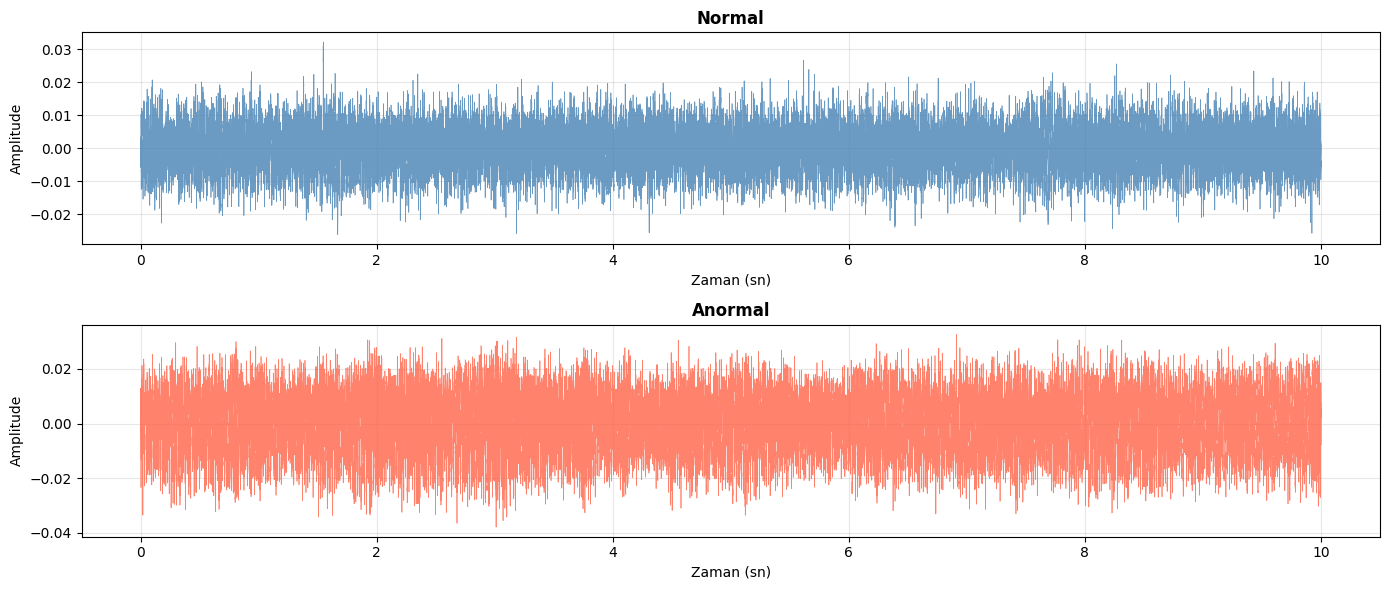

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
for ax, y, title, color in zip(axes,
    [y_normal, y_abnormal], ['Normal', 'Anormal'], ['steelblue', 'tomato']):
    t = np.linspace(0, len(y)/SAMPLE_RATE, len(y))
    ax.plot(t, y, color=color, lw=0.5, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Zaman (sn)'); ax.set_ylabel('Amplitude'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', '01_waveform.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Spektrogram ve MFCC

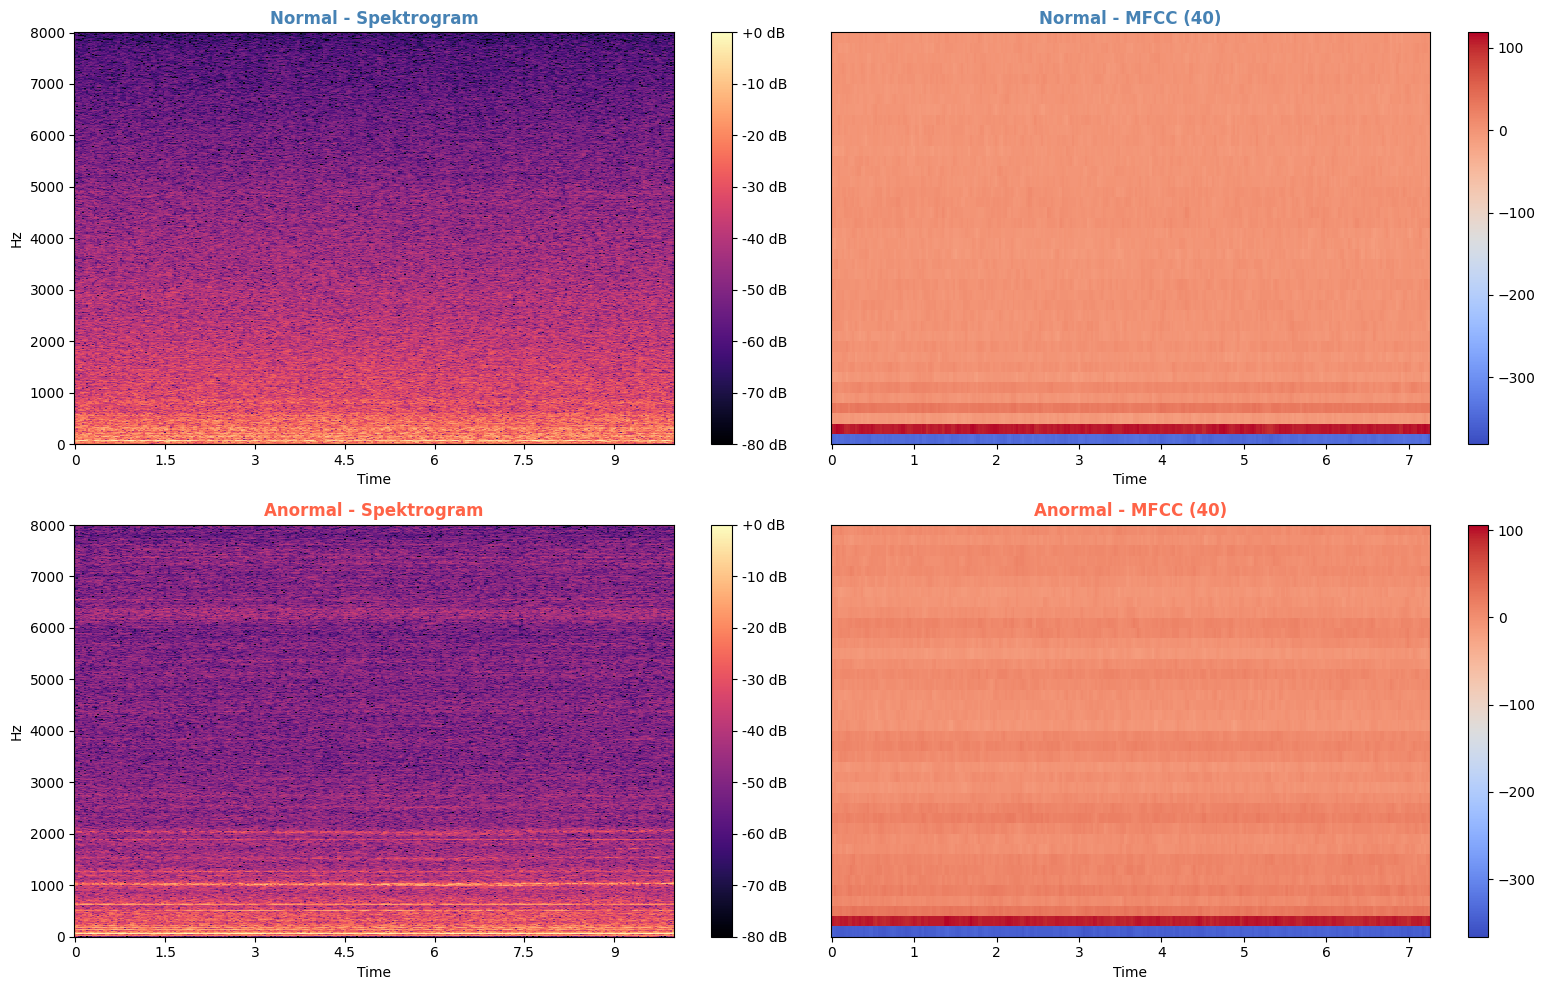

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for row, (y, color, title) in enumerate([
    (y_normal,   'steelblue', 'Normal'),
    (y_abnormal, 'tomato',    'Anormal')
]):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=SAMPLE_RATE, x_axis='time', y_axis='hz', ax=axes[row,0])
    axes[row,0].set_title(f'{title} - Spektrogram', color=color, fontweight='bold')
    plt.colorbar(img, ax=axes[row,0], format='%+2.0f dB')
    mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=40)
    img2 = librosa.display.specshow(mfcc, x_axis='time', ax=axes[row,1])
    axes[row,1].set_title(f'{title} - MFCC (40)', color=color, fontweight='bold')
    plt.colorbar(img2, ax=axes[row,1])
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', '02_spectrogram_mfcc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. MFCC Dağılımı

Özellikler çıkarılıyor (ilk 100 dosya)...


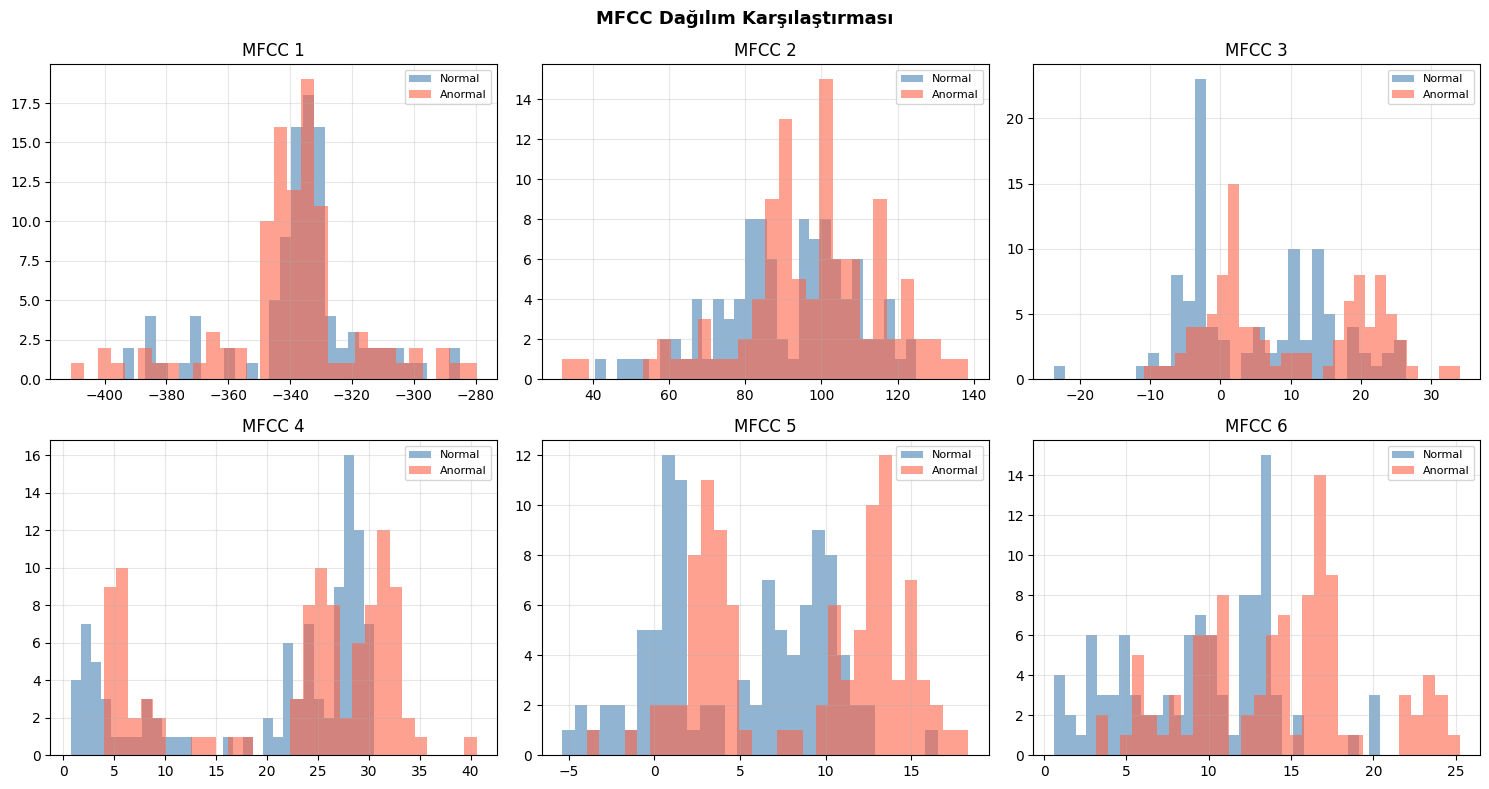

In [7]:
def mfcc_mean(fp):
    y = load_wav(fp)
    return np.mean(librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=13), axis=1)

print('Özellikler çıkarılıyor (ilk 100 dosya)...')
n_feats = np.array([mfcc_mean(f) for f in normal_files[:100]])
a_feats = np.array([mfcc_mean(f) for f in abnormal_files[:100]])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    ax.hist(n_feats[:, i], bins=30, alpha=0.6, color='steelblue', label='Normal')
    ax.hist(a_feats[:, i], bins=30, alpha=0.6, color='tomato',    label='Anormal')
    ax.set_title(f'MFCC {i+1}'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('MFCC Dağılım Karşılaştırması', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', '03_mfcc_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Tüm Model ID'ler Özeti

In [8]:
rows = []
for mid in ['id_00', 'id_02', 'id_04', 'id_06']:
    for lbl in ['normal', 'abnormal']:
        folder = os.path.join(BASE_DIR, 'data', 'raw', 'mimii', MACHINE_TYPE, mid, lbl)
        n = len(glob.glob(os.path.join(folder, '*.wav'))) if os.path.exists(folder) else 0
        rows.append({'Model ID': mid, 'Label': lbl, 'Dosya Sayısı': n})
display(pd.DataFrame(rows))
print('\n➡️  Sıradaki: 02_feature_extraction.ipynb')

,Model ID,Label,Dosya Sayısı
0,id_00,normal,1011
1,id_00,abnormal,407
2,id_02,normal,1016
3,id_02,abnormal,359
4,id_04,normal,1033
5,id_04,abnormal,348
6,id_06,normal,1015
7,id_06,abnormal,361



➡️  Sıradaki: 02_feature_extraction.ipynb
